# Heart Disease Prediction Assignment

**Name:** [Harsh Mishra]
**Date:** [Current Date]
**Estimated Time:** 2 hours

This notebook demonstrates building and evaluating a supervised machine learning model for heart disease prediction using the Heart Disease UCI dataset.

## Import Libraries

Import all necessary libraries for the assignment.

In [17]:
# TODO: Import the required libraries
# Required imports: pandas, numpy, sklearn modules (RandomForestClassifier, train_test_split,
#                  accuracy_score, confusion_matrix, classification_report, StandardScaler, etc.)
# Optional: matplotlib, seaborn for visualization, GridSearchCV for hyperparameter tuning
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler


---
## Task 1: Load & Understand the Data

Load the Heart Disease UCI dataset and explore its basic characteristics.

In [19]:
# TODO: Load the dataset
# Use pd.read_csv() to load 'heart.csv'
# Display the first few rows to understand the structure
df = pd.read_csv('/content/heart_disease_uci.csv')
df.head(1)



,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0


In [9]:
# TODO: Print dataset information
# Display:
# - Shape (rows/columns)

print("Data.shape:",df.shape)
df.describe()
# - Feature names & data types
# - Target variable distribution
# - Basic statistics using .describe()



Data.shape: (920, 16)


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [15]:
# TODO: Check for missing values and data quality
# Use .isnull().sum() to check for missing values
# Examine unique values in categorical columns (cp, thal, slope, etc.)
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


### Dataset Description (Max 75 words)

**Instructions:** Describe the dataset, mention the target variable, key features, and any notable observations about the data structure or quality.

**Your description:**
[Write your description here]

---
## Task 2: Preprocessing

Clean and prepare the data for machine learning model training.

In [16]:
# TODO: Handle missing values (if any)
# Check if there are missing values and decide whether to drop or impute
# Most heart disease datasets are clean, but verify this
df.describe()



,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [24]:
df.isna().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [30]:
df.drop(['id'], axis = 1, inplace=True)

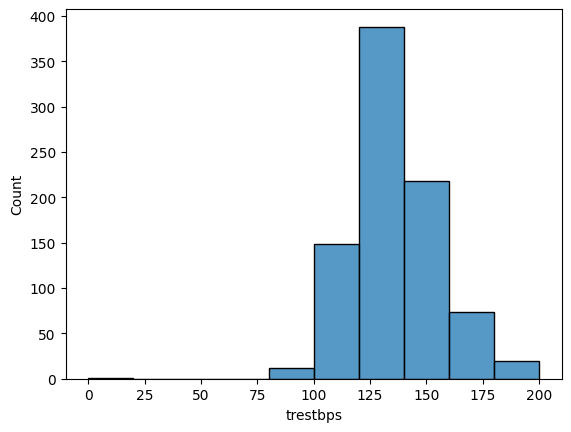

In [32]:
sns.histplot(df, x='trestbps',bins =10)
plt.show()

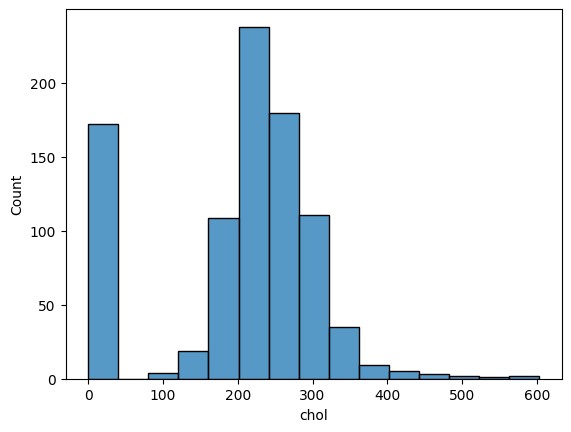

In [33]:
sns.histplot(df, x='chol',bins =15)
plt.show()

In [ ]:
# TODO: Encode categorical features
# Identify categorical columns (cp, thal, slope, etc.)
# Use appropriate encoding method (get_dummies, LabelEncoder, or leave as-is if already numeric)
# Consider which columns need encoding vs which are already properly formatted



265 411


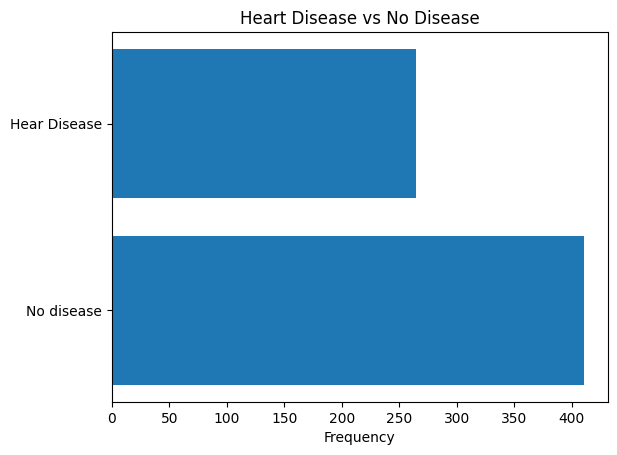

In [22]:
# TODO: Normalize or standardize numerical features
# Identify numerical columns that might benefit from scaling (age, trestbps, chol, etc.)
# Use StandardScaler or MinMaxScaler from sklearn.preprocessing
# Remember to fit on training data and transform both train and test
disease = len(df[df.num == 1])
no_disease = len(df[df.num == 0])
print(disease, no_disease)
plt.rcdefaults()
fig, ax = plt.subplots()
y = 'Hear Disease', 'No disease'
y_pos = np.arange(len(y))
x = (disease, no_disease)
ax.barh(y_pos, x, align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(y)
ax.invert_yaxis()
ax.set_xlabel('Frequency')
ax.set_title('Heart Disease vs No Disease')
plt.show()

In [ ]:
# TODO: Split into features (X) and target (y), then train/test sets
# Separate the target variable (typically 'target' or 'num') from features
# Use train_test_split with test_size=0.2 and random_state for reproducibility
# Consider using stratify parameter to maintain class balance



In [35]:
# Dealing with missing Values()
df_cleaned=  df.copy()

In [36]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   dataset   920 non-null    object 
 3   cp        920 non-null    object 
 4   trestbps  861 non-null    float64
 5   chol      890 non-null    float64
 6   fbs       830 non-null    object 
 7   restecg   918 non-null    object 
 8   thalch    865 non-null    float64
 9   exang     865 non-null    object 
 10  oldpeak   858 non-null    float64
 11  slope     611 non-null    object 
 12  ca        309 non-null    float64
 13  thal      434 non-null    object 
 14  num       920 non-null    int64  
dtypes: float64(5), int64(2), object(8)
memory usage: 107.9+ KB


### Preprocessing Steps Explanation (Max 75 words)

**Instructions:** Briefly explain your preprocessing choices - how you handled missing values, categorical encoding, and feature scaling decisions.

**Your explanation:**
[Write your explanation here]

In [37]:
df_cleaned.describe()

,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


---
## Task 3: Model Training & Evaluation

Train a Random Forest Classifier and evaluate its performance using multiple metrics.

In [41]:
#numeric columns

for col in ['trestbps','chol','oldpeak']:
  df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())
  print(col,df_cleaned[col].median())

for col in ['thalch']:
  df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mean())
  print(col,df_cleaned[col].mean())

trestbps 130.0
chol 223.0
oldpeak 0.5
thalch 137.5456647398844


In [43]:
# categorical columns

for col in ['fbs','exang','restecg']:
  col_mode = df_cleaned[col].mode()[0]
  print(col_mode)
  df_cleaned[col] = df_cleaned[col].fillna(col_mode)

False
False
normal


/tmp/ipython-input-2429473598.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cleaned[col] = df_cleaned[col].fillna(col_mode)


In [46]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   dataset   920 non-null    object 
 3   cp        920 non-null    object 
 4   trestbps  920 non-null    float64
 5   chol      920 non-null    float64
 6   fbs       920 non-null    bool   
 7   restecg   920 non-null    object 
 8   thalch    920 non-null    float64
 9   exang     920 non-null    bool   
 10  oldpeak   920 non-null    float64
 11  slope     611 non-null    object 
 12  ca        309 non-null    float64
 13  thal      434 non-null    object 
 14  num       920 non-null    int64  
dtypes: bool(2), float64(5), int64(2), object(6)
memory usage: 95.4+ KB


In [47]:
# Features design
def Cholesterol_group(chol):
  if chol < 200:
    return 0
  elif chol <=239:
    return 1
  elif chol <=299:
    return 2
  else:
    return 3
df_cleaned['Cholesterol_group'] = df_cleaned['chol'].apply(Cholesterol_group)


In [48]:
df_cleaned.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,Cholesterol_group
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,1
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,2
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,2
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,1


In [49]:
'''
sex: ['Male', 'Female']
datasetid: ['Cleveland', 'Hungarian', 'Switzerland', 'VA Long Beach .']
cp: ['typical angina','asymptomatic','non-anginal', 'atypical angina',  ]
fbs:[True False nan]
restecg: [''lv hypertrophy'normal', 'st-t wave abnormality', nan]
exang: [False true nan]
slope: ['downsloping','flat''upsloping'nan ]
thal: ['fixed defect', 'normal', 'reversable defect', nan]
'''
#

"\nsex: ['Male', 'Female']\ndatasetid: ['Cleveland', 'Hungarian', 'Switzerland', 'VA Long Beach .']\ncp: ['typical angina','asymptomatic','non-anginal', 'atypical angina',  ]\nfbs:[True False nan]\nrestecg: [''lv hypertrophy'normal', 'st-t wave abnormality', nan]\nexang: [False true nan]\nslope: ['downsloping','flat''upsloping'nan ]\nthal: ['fixed defect', 'normal', 'reversable defect', nan]\n"

In [51]:
df_encoded = pd.get_dummies(df_cleaned, columns=['dataset','cp','slope','thal'], dtype =int)
df_encoded.head()

,age,sex,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,ca,...,cp_asymptomatic,cp_atypical angina,cp_non-anginal,cp_typical angina,slope_downsloping,slope_flat,slope_upsloping,thal_fixed defect,thal_normal,thal_reversable defect
0,63,Male,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,0.0,...,0,0,0,1,1,0,0,1,0,0
1,67,Male,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,3.0,...,1,0,0,0,0,1,0,0,1,0
2,67,Male,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,2.0,...,1,0,0,0,0,1,0,0,0,1
3,37,Male,130.0,250.0,False,normal,187.0,False,3.5,0.0,...,0,0,1,0,1,0,0,0,1,0
4,41,Female,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,0.0,...,0,1,0,0,0,0,1,0,1,0


restecg_val ['lv hypertrophy', 'normal', 'st-t abnormality']


In [ ]:
# TODO: Train a Random Forest Classifier
# Create a RandomForestClassifier instance with random_state for reproducibility
# You can use default parameters or set n_estimators, max_depth, etc.
# Fit the model on training data
# Make predictions on test data



In [54]:
X = df_encoded.drop('num', axis = 1)
y = df_encoded['num']
#

In [56]:
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold

scoring = {'accuracy': 'accuracy',
           'precision': make_scorer(precision_score, average = "weighted", zero_division =0),
           'recall': make_scorer(recall_score, average = "weighted", zero_division =0),
           'f1': make_scorer(f1_score, average = "weighted", zero_division =0)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state= 8)

In [ ]:
# TODO: Evaluate using Accuracy
# Calculate accuracy score for both training and test sets
# Display the results in a clear format
# Check for potential overfitting by comparing train vs test accuracy



In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate
import pandas as pd # Import pandas if not already imported

SEED = 8 # Define SEED for reproducibility

# Encode the 'sex' column before splitting the data
df_encoded = pd.get_dummies(df_encoded, columns=['sex'], dtype=int)

X = df_encoded.drop('num', axis = 1)
y = df_encoded['num']

estimators = [RandomForestClassifier(class_weight ='balanced', random_state = SEED)]

for est in estimators:
  results = cross_validate(est, X, y, cv = cv, scoring = scoring, return_train_score = True)
  print("Model:", est.__class__.__name__)
  print("Mean Precision:", results['test_accuracy'].mean())
  print("Mean Recall:", results['test_recall'].mean())
  print("Mean F1:", results['test_f1'].mean(), f'\n')

Model: RandomForestClassifier
Mean Precision: 0.5858695652173913
Mean Recall: 0.5858695652173913
Mean F1: 0.5682717285530434 



In [ ]:
# TODO: Create and display Confusion Matrix
# Use confusion_matrix from sklearn.metrics
# Display the matrix in a readable format
# Optional: Use seaborn heatmap for better visualization
# Extract TP, TN, FP, FN for interpretation



In [ ]:
# TODO: Optional - Generate Classification Report
# Use classification_report to get precision, recall, and F1-score
# This provides detailed per-class performance metrics



In [ ]:
# TODO: Optional - Plot ROC Curve (if time allows)
# Import roc_curve and auc from sklearn.metrics
# Plot ROC curve using matplotlib
# Calculate and display AUC score



### Performance Summary (Max 100 words)

**Instructions:** Summarize the model's performance using accuracy, confusion matrix results, and any additional metrics you calculated. Comment on the model's effectiveness for heart disease prediction.

**Your summary:**
[Write your performance summary here]

---
## Bonus Task (Optional)

Choose one of the following improvement approaches to enhance your model.

### Option 1: Hyperparameter Tuning

In [61]:
# TODO: Optional - Hyperparameter Tuning using GridSearchCV
# Define parameter grid for Random Forest (n_estimators, max_depth, min_samples_split, etc.)
# Use GridSearchCV with cross-validation
# Compare best model performance with original model
# Note: This may take some time to run
from sklearn.model_selection import GridSearchCV


In [65]:
param_grid = {
    'max_depth' : [1,2,3,4],
    'num_leaves' : [2,4,8,16],
    'learning_rate': [0.05, 0.1, 0.2, 0.3],
    'n_estimators': [80,90,100,110]
}
from lightgbm import LGBMClassifier
grid = GridSearchCV(
    estimator = LGBMClassifier(objective = 'multiclass', class_weight = 'balanced', verbose = -1, random_state = SEED),
    param_grid = param_grid,
    scoring =scoring,
    refit ='f1',
    cv = 5,
    n_jobs = -1,
    verbose = 2
)

grid.fit(X,y)

Fitting 5 folds for each of 256 candidates, totalling 1280 fits


ValueError: 
All the 1280 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1280 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py", line 1560, in fit
    super().fit(
  File "/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py", line 972, in fit
    class_sample_weight = _LGBMComputeSampleWeight(self._class_weight, y)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_validation.py", line 206, in wrapper
    validate_parameter_constra

### Option 2: Feature Engineering

In [ ]:
# TODO: Optional - Create engineered features
# Ideas: BMI-like ratios, age groups, risk categories, interaction terms
# Example: Cholesterol-to-age ratio, blood pressure categories, etc.
# Test if the new feature improves model performance



### Bonus Task Summary

**Instructions:** If you completed a bonus task, provide 1-2 sentences summarizing what you tried and whether it improved the model performance.

**Your bonus summary:**
[Write your bonus summary here if completed]

---
## Feature Importance Analysis (Optional)

In [ ]:
# TODO: Optional - Analyze feature importance
# Random Forest provides feature_importances_ attribute
# Create a visualization showing which features are most important for prediction
# This can provide medical insights into heart disease risk factors



---
## Conclusion

**Instructions:** Write a brief overall conclusion about your analysis. Discuss the model's performance, key findings about heart disease prediction factors, and potential real-world applications or limitations.

**Your conclusion:**
[Write your conclusion here]

---
## Assignment Checklist

**Before submitting, ensure you have completed:**

### Task 1: Load & Understand Data ✓
- [ ] Loaded the heart.csv dataset
- [ ] Displayed dataset shape (rows/columns)
- [ ] Identified feature names & types
- [ ] Analyzed target variable distribution
- [ ] Written dataset description (max 75 words)

### Task 2: Preprocessing ✓
- [ ] Handled missing values (if any)
- [ ] Encoded categorical features appropriately
- [ ] Normalized/standardized numerical features
- [ ] Split data into train/test (80/20)
- [ ] Written preprocessing explanation (max 75 words)

### Task 3: Model Training & Evaluation ✓
- [ ] Trained Random Forest Classifier
- [ ] Calculated accuracy score
- [ ] Created confusion matrix
- [ ] Optional: Generated classification report
- [ ] Optional: Plotted ROC curve
- [ ] Written performance summary (max 100 words)

### Bonus Task (Optional) ✓
- [ ] Attempted hyperparameter tuning OR feature engineering
- [ ] Compared results with base model
- [ ] Written 1-2 sentence impact summary

### General Requirements ✓
- [ ] Code is clean, readable, and well-commented
- [ ] All markdown explanations are completed
- [ ] Notebook runs from top to bottom without errors
- [ ] All outputs are visible and properly formatted
- [ ] Word limits respected for all written sections
- [ ] Single .ipynb file ready for submission

---
## Additional Notes

**Dataset Information:**
- The Heart Disease UCI dataset typically contains 13-14 features
- Common features include: age, sex, cp (chest pain type), trestbps (resting blood pressure), chol (cholesterol), etc.
- Target variable usually indicates presence (1) or absence (0) of heart disease
- Dataset is generally clean with minimal missing values

**Evaluation Focus:**
- Code correctness & clarity (40%)
- Preprocessing & feature handling (25%)
- Model evaluation & metrics (25%)
- Bonus attempt (10%)

**Tips for Success:**
- Keep code clean and well-commented
- Test your notebook from top to bottom before submission
- Focus on clear explanations in markdown cells
- Consider the medical context when interpreting results